# NNsight for Protein Language Models: ESM Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NainaniJatinZ/plm_nnsight/blob/main/plm_nnsight.ipynb)

## Setup

Run this cell first to install dependencies and clone helpers.

In [1]:
# Detect environment and setup accordingly
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - setting up environment...")
    
    # Install uv for fast package management
    !pip install uv -q
    
    # Clone the repository to get helper files
    !git clone https://github.com/NainaniJatinZ/plm_nnsight.git /content/plm_nnsight 2>/dev/null || echo "Repo already cloned"
    
    # Install dependencies
    !uv pip install --system nnsight transformers torch matplotlib seaborn huggingface_hub safetensors -q
    
    # Add helpers to path
    sys.path.insert(0, '/content/plm_nnsight')
    print("Setup complete!")
else:
    print("Running locally - assuming dependencies are installed (see README.md for setup)")
    # Local setup: helpers are already in the repo

Running locally - assuming dependencies are installed (see README.md for setup)


## 1. Introduction

### Why NNsight?

When I first started working on protein language models (pLMs), most of the interpretability infrastructure was built for LLMs. The work we did for [plm circuits](https://github.com/NainaniJatinZ/plm_circuits/) used raw PyTorch hooks for caching and interventions.

Interpretability tooling has come a long way since then. **[NNsight](https://nnsight.net/)** is one of the strongest examples: it provides a clean interface for tracing activations, caching intermediate states, and performing interventions. Before starting my next pLM project, I wanted to port all my tools to NNsight. This tutorial documents that experience.

### Why Interpret Protein Language Models?

This question deserves its own post, but my reasoning boils down to two directions:

1. **Reliability**: Finding that models rely on incorrect patterns or spurious correlations is critical for trust - especially as pLMs are deployed in healthcare, drug design, and research.

2. **Discovery**: Finding that models have learned patterns *unknown to us* can generate new scientific hypotheses.

For a more principled case, see Goodfire's work on [Interpreting Evo-2](https://www.goodfire.ai/research/interpreting-evo-2) (look for "Why this matters").

### What This Tutorial Covers

- **Loading ESM2** with NNsight and understanding the wrapper
- **Accessing activations** from any layer, including attention patterns
- **Sparse Autoencoders**: loading pretrained SAEs and running interventions
- **Practical patterns** for caching, batching, and debugging

### Notation

Throughout this tutorial, we use **shape suffixes** to make tensor dimensions obvious at a glance:

| Suffix | Meaning |
|--------|---------|
| `B` | Batch size |
| `L` | Sequence length (including special tokens) |
| `A` | Amino acid positions (excluding special tokens) |
| `H` | Attention heads |
| `D` | Hidden dimension |
| `V` | Vocabulary size |
| `F` | SAE feature dimension |
| `K` | Top-k |
| `S` | String length |

For example, `attn_weights_BHLL` is a tensor with shape `(batch, heads, seq_len, seq_len)`.

## 2. Loading the Model

We'll use ESM2-650M, a protein language model trained on ~65 million protein sequences. The model has 33 transformer layers with 20 attention heads each.

In [2]:
from __future__ import annotations
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import EsmForMaskedLM, EsmTokenizer
from nnsight import NNsight

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "facebook/esm2_t33_650M_UR50D"  # 650M param model, 33 layers
esm_model = EsmForMaskedLM.from_pretrained(
    model_name,
    attn_implementation="eager"  # Required for output_attentions=True
).to(device)
tokenizer = EsmTokenizer.from_pretrained(model_name)

print(f"Loaded {model_name}")
print(f"  Layers: {esm_model.config.num_hidden_layers}")
print(f"  Hidden size: {esm_model.config.hidden_size}")
print(f"  Attention heads: {esm_model.config.num_attention_heads}")

Using device: cuda
Loaded facebook/esm2_t33_650M_UR50D
  Layers: 33
  Hidden size: 1280
  Attention heads: 20


### 2.1 Wrapping with NNsight

NNsight wraps your model to enable tracing and intervention. The wrapper is transparent—you can still use the model normally.

**Note on naming**: ESM's transformer layers have a submodule called `.output` (the `EsmOutput` class). NNsight uses `.output` to access a module's output tensor. To avoid conflicts, NNsight renames the module accessor to `.nns_output` when there's a collision. You'll see a warning about this—it's expected.

In [ ]:
model = NNsight(esm_model)

You should see a bunch of the following: 
```
<path>/jatin/plm_nnsight/.plm_nn/lib/python3.11/site-packages/nnsight/intervention/envoy.py:823: UserWarning: Module `model.esm.encoder.layer.0.attention` of type `<class 'transformers.models.esm.modeling_esm.EsmAttention'>` has pre-defined a `output` attribute. nnsight access for `output` will be mounted at `.nns_output` instead of `.output` for this module only.
  warnings.warn(
...
```


### 2.2 Example Input

We'll use a real protein sequence throughout this tutorial. ESM tokenizes each amino acid as a single token, plus special tokens `<cls>` at the start and `<eos>` at the end.

**Our example**: MetXA (Homoserine O-acetyltransferase) from *Haemophilus influenzae* — a 377-residue enzyme we investigated in [plm-circuits](https://github.com/NainaniJatinZ/plm_circuits). See it on [UniProt](https://www.uniprot.org/uniprotkb/P45131/entry) or [PDB](https://www.rcsb.org/structure/2B61).

In [5]:
# Example protein: MetXA (Homoserine O-acetyltransferase), PDB 2B61 chain A
# 377 amino acid enzyme - a good size for demonstration
sequence_S = (
    "GSSHHHHHHSSGLVPRGSHMSVQNVVLFDTQPLTLMLGGKLSYINVAYQTYGTLNDEKNNAVLICHALTGDAEPYFDDGRDGWWQNFMGAGLALDTDRYFFISSNVLGGCKGTTGPSSINPQTGKPYGSQFPNIVVQDIVKVQKALLEHLGISHLKAIIGGSFGGMQANQWAIDYPDFMDNIVNLCSSIYFSAEAIGFNHVMRQAVINDPNFNGGDYYEGTPPDQGLSIARMLGMLTYRTDLQLAKAFGRATKSDGSFWGDYFQVESYLSYQGKKFLERFDANSYLHLLRALDMYDPSLGYENVKEALSRIKARYTLVSVTTDQLFKPIDLYKSKQLLEQSGVDLHFYEFPSDYGHDAFLVDYDQFEKRIRDGLAGN"
)

inputs_BL = tokenizer(sequence_S, return_tensors="pt").to(device)

print(f"Sequence length: {len(sequence_S)} amino acids")
print(f"Tokenized shape: {inputs_BL['input_ids'].shape}  (includes <cls> and <eos> tokens)")
print(f"First 50 residues: {sequence_S[:50]}...")

Sequence length: 377 amino acids
Tokenized shape: torch.Size([1, 379])  (includes <cls> and <eos> tokens)
First 50 residues: GSSHHHHHHSSGLVPRGSHMSVQNVVLFDTQPLTLMLGGKLSYINVAYQT...


## 3. Accessing Activations

NNsight's core feature is **tracing**: running your model while recording (or modifying) intermediate activations. Let's start with a basic comparison.

In [6]:
# Normal forward pass (no tracing) - the model still works as usual
with torch.no_grad():
    normal_output = esm_model(**inputs_BL)
normal_logits_BLV = normal_output.logits
print(f"Normal forward pass - logits shape: {normal_logits_BLV.shape}")

Normal forward pass - logits shape: torch.Size([1, 379, 33])


In [7]:
# Traced forward pass - access intermediate activations with .save()
#
# Key pattern: use model.trace() context, then tracer.invoke() to run
# For models with keyword-only inputs (like ESM), use: tracer.invoke(**inputs_BL)

with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Save a middle layer's output (layer 16 of 33)
        # Use .nns_output because ESM layers have an .output submodule
        layer_16_out_BLD = model.esm.encoder.layer[16].nns_output.save()
        
        # Save final logits
        logits_BLV = model.lm_head.output.save()

print(f"Layer 16 hidden states: {layer_16_out_BLD.shape}")
print(f"Final logits: {logits_BLV.shape}")

Layer 16 hidden states: torch.Size([1, 379, 1280])
Final logits: torch.Size([1, 379, 33])


#### `.output` vs `.nns_output` — When to Use Which?

NNsight uses `.output` to access any module's output tensor. But ESM has some submodules literally named `output` (the `EsmOutput` class), causing a naming collision.

**The rule:**
- Use `.output` by default (e.g., `model.lm_head.output`, `layer[i].attention.self.output`)
- Use `.nns_output` when the module has a child named `output` (e.g., `layer[i].nns_output`)

**How to check:** If you see NNsight's warning about renaming `.output` → `.nns_output`, that module needs `.nns_output`. Or inspect the model:

```python
# This has an .output submodule, so use .nns_output
print(type(esm_model.esm.encoder.layer[0].output))  # <class 'EsmOutput'>

# This doesn't, so use .output
print(hasattr(esm_model.esm.encoder.layer[0].attention.self, 'output'))  # False
```

### 3.1 Attention Patterns

Attention weights reveal which positions the model attends to when processing each residue. To get them, we need:

1. `output_attentions=True` in the forward pass
2. `attn_implementation="eager"` when loading (SDPA doesn't return weights)
3. Access `.attention.self` (where Q, K, V live), not just `.attention`

**ESM attention structure:**
- `layer[i].attention` = EsmAttention (output projection + LayerNorm)
- `layer[i].attention.self` = EsmSelfAttention (Q, K, V computation)

In [8]:
# Run with attention outputs enabled
inputs_with_attn_BL = {**inputs_BL, "output_attentions": True}

with model.trace() as tracer:
    with tracer.invoke(**inputs_with_attn_BL):
        # Access the SELF-ATTENTION module to get (context, attention_weights) tuple
        # .attention.self is where Q, K, V are computed and attention weights are generated
        attn_out_0_BLD_BHLL = model.esm.encoder.layer[0].attention.self.output.save()
        attn_out_16_BLD_BHLL = model.esm.encoder.layer[16].attention.self.output.save()
        attn_out_32_BLD_BHLL = model.esm.encoder.layer[32].attention.self.output.save()

# Check what we got - should be tuples now with eager attention
print(f"Layer 0 attention output type: {type(attn_out_0_BLD_BHLL)}")
if isinstance(attn_out_0_BLD_BHLL, tuple) and len(attn_out_0_BLD_BHLL) > 1:
    print(f"  Context shape: {attn_out_0_BLD_BHLL[0].shape}")  # (batch, seq, hidden)
    print(f"  Attention weights shape: {attn_out_0_BLD_BHLL[1].shape}")  # (batch, heads, seq, seq)
else:
    print(f"  Shape: {attn_out_0_BLD_BHLL.shape}")
    print("  WARNING: Expected tuple with attention weights. Did you load with attn_implementation='eager'?")

Layer 0 attention output type: <class 'tuple'>
  Context shape: torch.Size([1, 379, 1280])
  Attention weights shape: torch.Size([1, 20, 379, 379])


In [9]:
def plot_attention_head(attn_weights_BHLL, layer_idx, head_idx, tokens_BL, ax=None):
    """Plot a single attention head's pattern."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # attn_weights shape: (batch, heads, seq_len, seq_len)
    head_attn_LL = attn_weights_BHLL[0, head_idx].cpu().detach().numpy()

    # Create labels from tokens (skip special tokens for readability)
    seq_len = head_attn_LL.shape[0]
    labels_L = [tokenizer.decode([t]) for t in tokens_BL[0][:seq_len]]

    sns.heatmap(head_attn_LL, ax=ax, cmap='viridis',
                xticklabels=labels_L, yticklabels=labels_L,
                square=True, cbar_kws={'shrink': 0.5})
    ax.set_title(f'Layer {layer_idx}, Head {head_idx}')
    ax.set_xlabel('Key position', labelpad=2)   # Decrease labelpad to bring label closer
    ax.set_ylabel('Query position', labelpad=2) # Decrease labelpad to bring label closer

    return ax

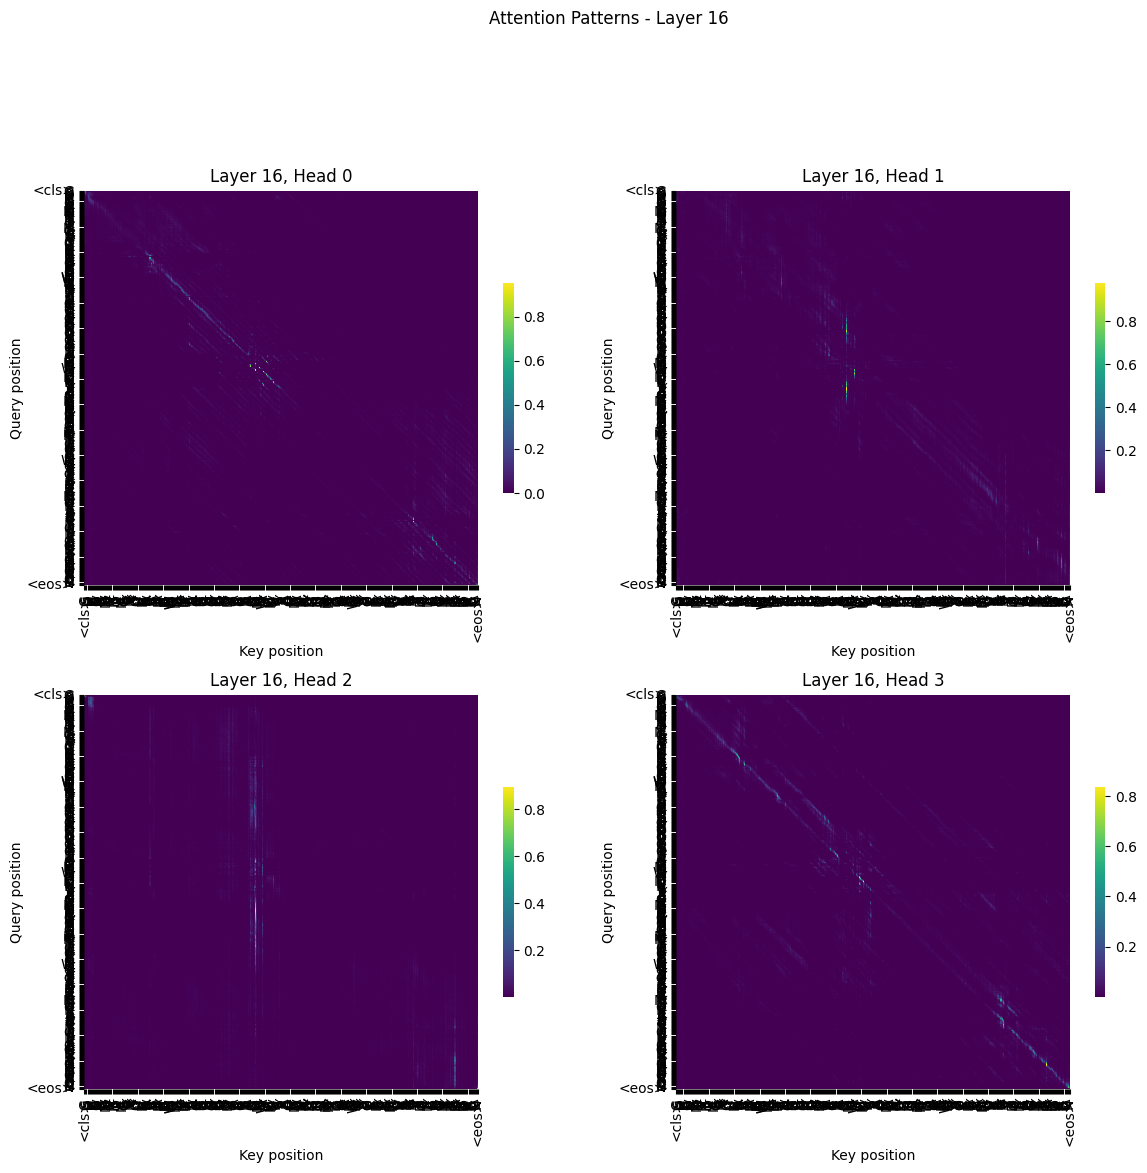

In [12]:
attn_weights_BHLL = attn_out_16_BLD_BHLL[1]  # Shape: (batch, heads, seq, seq)
n_heads = attn_weights_BHLL.shape[1]

# Plot first 4 heads
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for i, ax in enumerate(axes.flat):
    if i < n_heads:
        plot_attention_head(attn_weights_BHLL, layer_idx=16, head_idx=i,
                            tokens_BL=inputs_BL['input_ids'], ax=ax)
plt.suptitle('Attention Patterns - Layer 16', y=1.02)
plt.show()

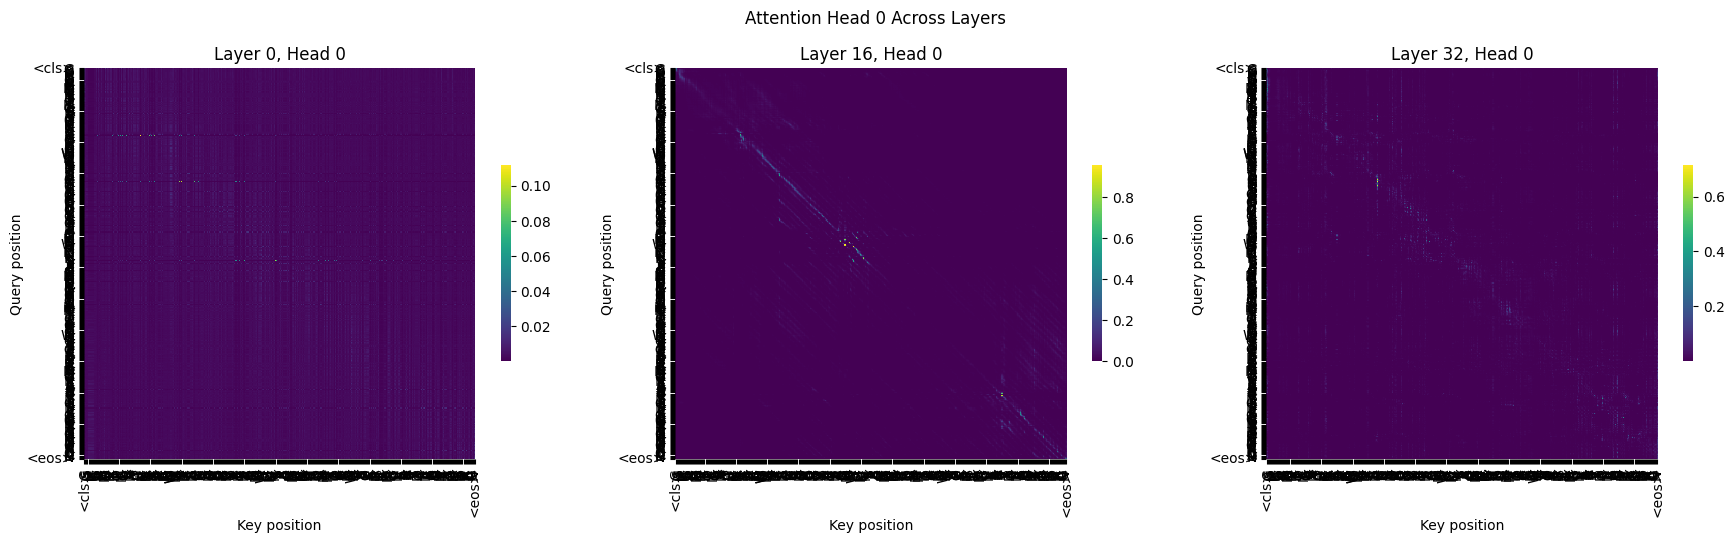

In [11]:
# Compare attention across layers (head 0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (layer_idx, attn_out) in zip(axes, [
    (0, attn_out_0_BLD_BHLL), (16, attn_out_16_BLD_BHLL), (32, attn_out_32_BLD_BHLL)
]):
    if isinstance(attn_out, tuple) and len(attn_out) > 1:
        plot_attention_head(attn_out[1], layer_idx=layer_idx, head_idx=0,
                          tokens_BL=inputs_BL['input_ids'], ax=ax)

plt.suptitle('Attention Head 0 Across Layers', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Batch Caching

For larger analyses, you can cache all layer outputs at once using `tracer.cache()`. This is more efficient than saving outputs one by one.

In [13]:
# Cache all layer outputs in one pass
with model.trace() as tracer:
    with tracer.invoke(**inputs_with_attn_BL):
        cache = tracer.cache(
            modules=[model.esm.encoder.layer[i].attention.self for i in range(33)]
        )

print(f"Cached {len(cache)} modules")
print(f"Keys: {list(cache.keys())[:3]}...")

# Extract all attention weights
all_attention_BHLL = []
for i in range(33):
    key = f"model.esm.encoder.layer.{i}.attention.self"
    if key in cache:
        out_BLD_BHLL = cache[key].output
        if isinstance(out_BLD_BHLL, tuple) and len(out_BLD_BHLL) > 1:
            all_attention_BHLL.append(out_BLD_BHLL[1])  # attention weights

print(f"Collected attention from {len(all_attention_BHLL)} layers")
if all_attention_BHLL:
    print(f"Shape per layer: {all_attention_BHLL[0].shape}")

Cached 33 modules
Keys: ['model.esm.encoder.layer.0.attention.self', 'model.esm.encoder.layer.1.attention.self', 'model.esm.encoder.layer.2.attention.self']...
Collected attention from 33 layers
Shape per layer: torch.Size([1, 20, 379, 379])


## 4. Sparse Autoencoders

Sparse Autoencoders (SAEs) learn to decompose neural network activations into sparse, interpretable features. The [InterProt](https://github.com/etowahadams/interprot) project trained SAEs on ESM2 layers, which we can load and use for analysis. We plan to add quick switching between [Interplm](https://interplm.ai/) SAEs soon, but most of the logic remains the same. 

**SAE architecture:**
- **Encoder**: hidden_state → sparse latent (with top-k sparsity)
- **Decoder**: sparse latent → reconstructed hidden_state

**Key insight**: If an SAE reconstructs well (low error) while being sparse, the latent dimensions may correspond to interpretable features the model uses internally.

In [14]:
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from helpers.sae_model_interprot import SparseAutoencoder

def load_sae_prot(esm_dim=1280, sae_dim=4096, layer=24, device="cuda"):
    """Load a Sparse Autoencoder trained for a specific ESM layer.

    Available layers: 6, 12, 18, 24, 30 (for ESM2-650M)
    Available SAE dims: 4096, 8192, 16384
    """
    checkpoint_path = hf_hub_download(
        repo_id="liambai/InterProt-ESM2-SAEs",
        filename=f"esm2_plm{esm_dim}_l{layer}_sae{sae_dim}.safetensors"
    )
    sae = SparseAutoencoder(esm_dim, sae_dim)
    sae.load_state_dict(load_file(checkpoint_path))
    sae.to(device).eval()
    return sae

In [15]:
# Load SAE for layer 24 (a commonly analyzed layer)
LAYER_IDX = 24
sae = load_sae_prot(esm_dim=1280, sae_dim=4096, layer=LAYER_IDX, device=device)

print(f"Loaded SAE for layer {LAYER_IDX}")
print(f"  Input dim (d_model): {sae.d_model}")
print(f"  Hidden dim (d_hidden): {sae.d_hidden}")
print(f"  Top-k sparsity: {sae.k}")

Loaded SAE for layer 24
  Input dim (d_model): 1280
  Hidden dim (d_hidden): 4096
  Top-k sparsity: 128


### 4.1 Running the SAE Forward Pass

Let's extract activations and run them through the SAE. Note we exclude special tokens (`<cls>`, `<eos>`) since the SAE was trained only on amino acid positions.

In [16]:
# Get layer activations using NNsight trace
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the hidden states from layer 24
        # ESM layers return (hidden_states, attention_weights) tuple
        layer_hidden_BLD = model.esm.encoder.layer[LAYER_IDX].nns_output.save()

print(f"Layer {LAYER_IDX} hidden states shape: {layer_hidden_BLD.shape}")

Layer 24 hidden states shape: torch.Size([1, 379, 1280])


In [17]:
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get layer hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output # we do LAYER_IDX-1 because of how Adams et al. indexed the layers 

        # Extract AA tokens only (exclude special tokens)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # Call SAE inside the trace (ad-hoc module call)
        # This runs the SAE on the live tensor during inference
        sae_output_BAD = sae.forward_val(aa_hidden_BAD).save()

        # Also save original AA hidden for comparison
        original_aa_hidden_BAD = aa_hidden_BAD.save()

print(f"Original AA hidden shape: {original_aa_hidden_BAD.shape}")
print(f"SAE output shape: {sae_output_BAD.shape}")

Original AA hidden shape: torch.Size([1, 377, 1280])
SAE output shape: torch.Size([1, 377, 1280])


### 4.2 SAE Reconstruction Quality

Let's test how well the SAE reconstructs activations by comparing model outputs with and without the SAE in the loop.

In [18]:
# First, get baseline logits (no intervention) for comparison
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        baseline_logits_BLV = model.lm_head.output.save()

print(f"Baseline logits shape: {baseline_logits_BLV.shape}")

Baseline logits shape: torch.Size([1, 379, 33])


In [19]:
# Now, sae intervention: replace layer output with SAE reconstruction
# Here, we only modify AA positions, keep special tokens unchanged
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the layer's hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output

        # Extract AA tokens only (exclude <cls> at 0 and <eos> at -1)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # Compute SAE reconstruction on AA tokens only
        sae_recon_aa_BAD = sae.forward_val(aa_hidden_BAD)

        # INTERVENTION: Replace only the AA positions with SAE reconstruction
        # Keep <cls> and <eos> unchanged
        model.esm.encoder.layer[LAYER_IDX-1].nns_output[:, 1:-1, :] = sae_recon_aa_BAD

        # Get logits after intervention
        sae_logits_BLV = model.lm_head.output.save()

print(f"Intervened logits shape: {sae_logits_BLV.shape}")

Intervened logits shape: torch.Size([1, 379, 33])


In [20]:
# Compare baseline vs intervened predictions
def top_k_tokens(logits_BLV, tokenizer, k=5):
    """Get top-k predicted tokens for each position."""
    probs_BLV = torch.softmax(logits_BLV, dim=-1)
    top_probs_BLK, top_ids_BLK = probs_BLV.topk(k, dim=-1)
    return top_ids_BLK, top_probs_BLK

baseline_top_BLK, baseline_probs_BLK = top_k_tokens(baseline_logits_BLV[0], tokenizer)
sae_top_BLK, sae_probs_BLK = top_k_tokens(sae_logits_BLV[0], tokenizer)

# Check if top predictions match
top1_match = (baseline_top_BLK[:, 0] == sae_top_BLK[:, 0]).float().mean().item()
print(f"Top-1 prediction match rate: {top1_match:.1%}")

# Logit difference
logit_diff = (baseline_logits_BLV - sae_logits_BLV).abs().mean().item()
print(f"Mean absolute logit difference: {logit_diff:.4f}")

# KL divergence between distributions
baseline_log_probs_BLV = torch.log_softmax(baseline_logits_BLV, dim=-1)
sae_probs_full_BLV = torch.softmax(sae_logits_BLV, dim=-1)
kl_div = (sae_probs_full_BLV * (torch.log_softmax(sae_logits_BLV, dim=-1) - baseline_log_probs_BLV)).sum(dim=-1).mean().item()
print(f"KL divergence (sae || baseline): {kl_div:.4f}")


Top-1 prediction match rate: 95.0%
Mean absolute logit difference: 1.0963
KL divergence (sae || baseline): 0.5577


### 4.3 Intervening on SAE Latents

We can modify specific latent dimensions and observe the effect on model behavior. Here's a toy example that zeros out all latents (a destructive intervention that should hurt performance).

In [21]:

with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the layer's hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output

        # Extract AA tokens only (exclude <cls> at 0 and <eos> at -1)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # SAE recreating encoder forward 
        x, mu_F, std_F = sae.LN(aa_hidden_BAD)
        f_BAS = (x - sae.b_pre) @ sae.w_enc + sae.b_enc

        # toy intervention: set all latents to 0
        f_BAS[:, :, :] = 0

        topk_BAS = sae.topK_activation(f_BAS, sae.k)

        sae_recon_aa_BAD = (topk_BAS @ sae.w_dec + sae.b_pre) * std_F + mu_F

        # INTERVENTION: Replace only the AA positions with SAE reconstruction
        # Keep <cls> and <eos> unchanged
        model.esm.encoder.layer[LAYER_IDX-1].nns_output[:, 1:-1, :] = sae_recon_aa_BAD

        # Get logits after intervention
        intervened_logits_BLV = model.lm_head.output.save()

print(f"Intervened logits shape: {intervened_logits_BLV.shape}")

Intervened logits shape: torch.Size([1, 379, 33])


In [22]:
# Compare baseline vs intervened predictions
def top_k_tokens(logits_BLV, tokenizer, k=5):
    """Get top-k predicted tokens for each position."""
    probs_BLV = torch.softmax(logits_BLV, dim=-1)
    top_probs_BLK, top_ids_BLK = probs_BLV.topk(k, dim=-1)
    return top_ids_BLK, top_probs_BLK

baseline_top_BLK, baseline_probs_BLK = top_k_tokens(baseline_logits_BLV[0], tokenizer)
interv_top_BLK, interv_probs_BLK = top_k_tokens(intervened_logits_BLV[0], tokenizer)

# Check if top predictions match
top1_match = (baseline_top_BLK[:, 0] == interv_top_BLK[:, 0]).float().mean().item()
print(f"Top-1 prediction match rate: {top1_match:.1%}")

# Logit difference
logit_diff = (baseline_logits_BLV - intervened_logits_BLV).abs().mean().item()
print(f"Mean absolute logit difference: {logit_diff:.4f}")

# KL divergence between distributions
baseline_log_probs_BLV = torch.log_softmax(baseline_logits_BLV, dim=-1)
interv_probs_full_BLV = torch.softmax(intervened_logits_BLV, dim=-1)
kl_div = (interv_probs_full_BLV * (torch.log_softmax(intervened_logits_BLV, dim=-1) - baseline_log_probs_BLV)).sum(dim=-1).mean().item()
print(f"KL divergence (intervened || baseline): {kl_div:.4f}")


Top-1 prediction match rate: 7.7%
Mean absolute logit difference: 3.3827
KL divergence (intervened || baseline): 4.9162


## 5. Next Steps: pLM Circuits

This section will cover more advanced techniques for mechanistic interpretability of protein language models.

**Coming soon:**
- Activation patching and attribution patching
- Finding causally important latents for contact prediction
- Visualizing results on 3D protein structures

For now, see the [plm_circuits repository](https://github.com/NainaniJatinZ/plm_circuits/) for the original implementation.

## Conclusion

This tutorial covered the basics of using NNsight with ESM2:

1. **Loading & wrapping** - NNsight wraps any PyTorch model transparently
2. **Tracing activations** - Use `.save()` to capture intermediate states
3. **Attention analysis** - Access attention weights with `output_attentions=True`
4. **SAE interventions** - Decompose and modify activations through sparse features

NNsight makes interpretability workflows much cleaner than raw PyTorch hooks. The patterns here generalize to other transformer models—just watch for naming conflicts (like `.output`) and model-specific quirks.

**Questions or issues?** Open an issue on [GitHub](https://github.com/NainaniJatinZ/plm_nnsight) or reach out on Twitter/X [zephyr_wade](https://x.com/zephyr_wade).

---

*Tutorial by [Jatin Nainani](https://nainanijatinz.github.io/). Built with [NNsight](https://nnsight.net/).*